<a href="https://colab.research.google.com/github/miriam-silva/ProvaIcomaAM/blob/main/prova_01_miriam_silva.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline 1 | Extração e Carregamento de Dados [Fase 1]

## Bibliotecas Python

In [103]:
import requests
import pandas as pd

## Consumo da API (Alpha Vantage)

In [104]:
API_KEY = '4UAUPZP06FCMODZI'
url = f'https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=IBM&apikey={API_KEY}&outputsize=compact'
response = requests.get(url)
data = response.json()

## Transformação para DataFrame

In [105]:
if 'Time Series (Daily)' in data:
  df = pd.DataFrame.from_dict(data['Time Series (Daily)'], orient='index')
  df.columns = ['open', 'high', 'low', 'close', 'volume']
  df = df.astype(float)
  df.index = pd.to_datetime(df.index)
  df = df.sort_index()
else:
  print("Erro na API:")
  print(data)

In [106]:
df.head()

,open,high,low,close,volume
2025-12-09,309.630,313.9700,308.7500,310.48,2914275.0
2025-12-10,310.230,314.6900,306.6513,312.67,3411524.0
2025-12-11,312.000,313.4400,308.4000,310.74,2755749.0
2025-12-12,310.570,311.0500,303.3300,309.24,2953374.0
2025-12-15,308.985,311.3629,306.3500,308.66,3566732.0


# Pipeline 2 | Tratamento e Normalização [Fase 2]

## Bibliotecas

In [107]:
import numpy as np
from sklearn.preprocessing import StandardScaler

## Verificação de valores nulos

In [108]:
df.isnull().sum()

,0
open,0
high,0
low,0
close,0
volume,0


## Conversão de tipos (apenas dados numéricos)

In [109]:
df = df.astype(float)

## Tratamento de assimetria (volume)

In [110]:
df['volume_log'] = np.log1p(df['volume'])

## Criação de novas features (melhoria de desempenho)

In [111]:
df['range'] = df['high'] - df['low']
df['body'] = df['close'] - df['open']
df['mean_price'] = (df['high'] - df['low']) / 2
df['variation'] = (df['close'] - df['open']) / df['open']
df['return'] = df['close'].pct_change()
df['ma3'] = df['close'].rolling(window=3).mean()
df['ma7'] = df['close'].rolling(window=7).mean()

## Remoção de valores nulos gerados

In [112]:
df.dropna(inplace=True)

## Separação de variáveis preditoras (X)

In [113]:
X = df[['open', 'high', 'low', 'close', 'volume_log', 'range', 'body', 'mean_price', 'variation', 'return', 'ma3', 'ma7']]

## Normalização dos dados (StandardScaler)

In [114]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Pipeline 3 | Visualização de Dados [Fase 3]

## Bibliotecas para visualização

In [115]:
import matplotlib.pyplot as plt
import seaborn as sns

## Visualização inicial dos dados

In [116]:
df.head()

,open,high,low,close,volume,volume_log,range,body,mean_price,variation,return,ma3,ma7
2025-12-17,303.79,306.25,303.08,303.32,3130954.0,14.956849,3.17,-0.47,1.585,-0.001547,0.000462,305.053333,308.327143
2025-12-18,303.15,304.45,295.70,300.45,5411669.0,15.504068,8.75,-2.70,4.375,-0.008906,-0.009462,302.316667,306.894286
2025-12-19,300.35,306.86,299.10,300.98,11031341.0,16.216251,7.76,0.63,3.880,0.002098,0.001764,301.583333,305.224286
2025-12-22,301.03,303.18,298.32,302.79,2612100.0,14.775665,4.86,1.76,2.430,0.005847,0.006014,301.406667,304.088571
2025-12-23,301.34,305.13,300.65,303.78,2923037.0,14.888134,4.48,2.44,2.240,0.008097,0.003270,302.516667,303.308571


## Verificação de valores únicos

In [117]:
df['volume'].nunique()

94

## Gráfico de fechamento

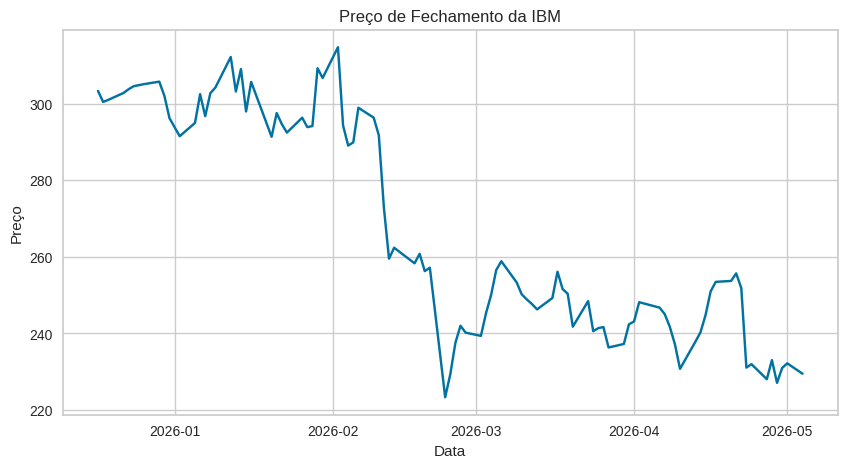

In [118]:
plt.figure(figsize=(10,5))
plt.plot(df['close'])

plt.title('Preço de Fechamento da IBM')
plt.xlabel('Data')
plt.ylabel('Preço')
plt.show()

## Histograma de fechamento

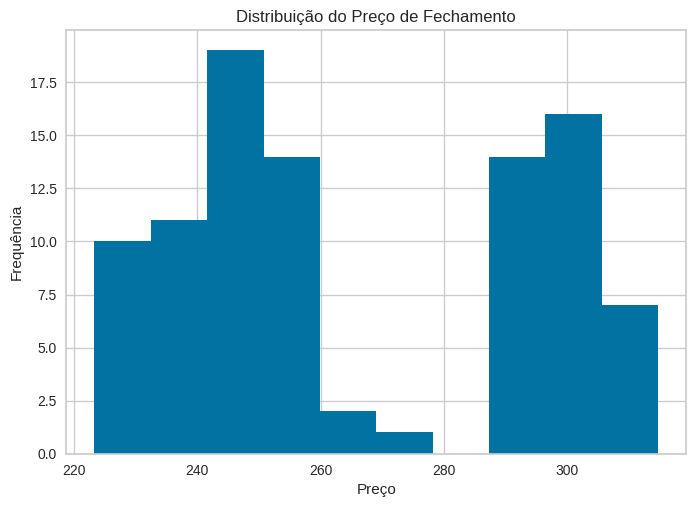

In [119]:
plt.hist(df['close'], bins=10)

plt.title('Distribuição do Preço de Fechamento')
plt.xlabel('Preço')
plt.ylabel('Frequência')
plt.show()

## Histograma do volume

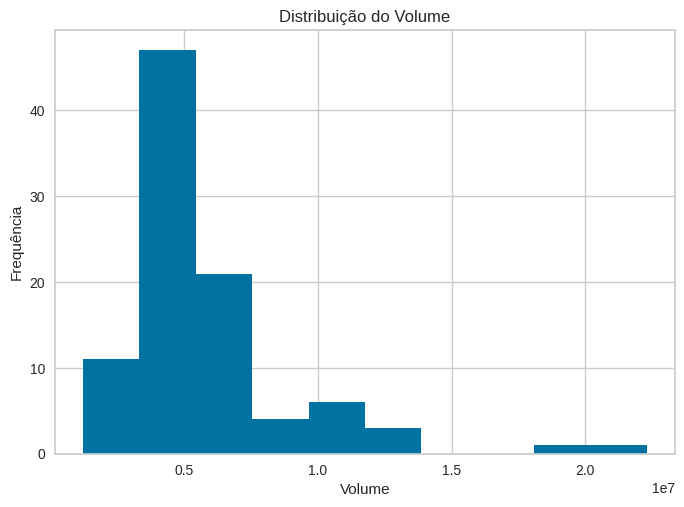

In [120]:
plt.hist(df['volume'], bins=10)

plt.title('Distribuição do Volume')
plt.xlabel('Volume')
plt.ylabel('Frequência')
plt.show()

## Histograma do volume tratado

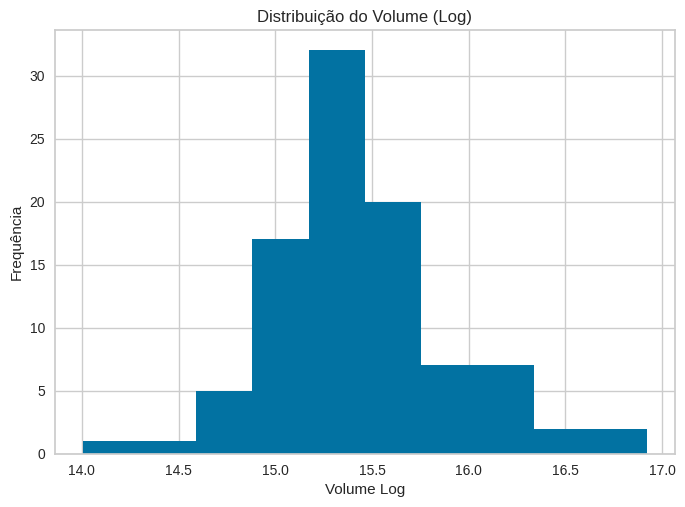

In [121]:
plt.hist(df['volume_log'], bins=10)

plt.title('Distribuição do Volume (Log)')
plt.xlabel('Volume Log')
plt.ylabel('Frequência')
plt.show()

# Pipeline 4 | Laborização [Fase 4]

## Criação da variável alvo (target)

In [122]:
df['target'] = (df['close'] > df['open']).astype(int)

## Verificação da variável alvo criada

In [123]:
df[['open', 'close', 'target']].head()

,open,close,target
2025-12-17,303.79,303.32,0
2025-12-18,303.15,300.45,0
2025-12-19,300.35,300.98,1
2025-12-22,301.03,302.79,1
2025-12-23,301.34,303.78,1


## Separação das variáveis preditoras (X) e variável alvo (Y)

In [124]:
X = X_scaled
y = df['target']

# Pipeline 5 | Ingestão Bayesiana [Fase 5]

## Bibliotecas para modelagem

In [125]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Divisão dos dados em treino e teste

In [126]:
tamanho_treino = int(len(X) * 0.9)

X_train = X[:tamanho_treino]
X_test = X[tamanho_treino:]

y_train = y[:tamanho_treino]
y_test = y[tamanho_treino:]

## Criação do modelo Naive Bayes Gaussiano

In [127]:
modelo = GaussianNB(priors=[0.5, 0.5])

## Treinamento do modelo

In [128]:
modelo.fit(X_train, y_train)

GaussianNB(priors=[0.5, 0.5])

## Realização das previsões

In [129]:
y_pred = modelo.predict(X_test)

## Avaliação do modelo (métrica principal - acurácia)

In [130]:
acuracia = accuracy_score(y_test, y_pred)

In [131]:
print("Acurácia do modelo:", acuracia)

Acurácia do modelo: 0.9


## Matriz de confusão

In [132]:
matriz = confusion_matrix(y_test, y_pred)
print("Matriz de confusão:")
print(matriz)

Matriz de confusão:
[[5 1]
 [0 4]]


## Vizualização da matriz de confusão

0.9

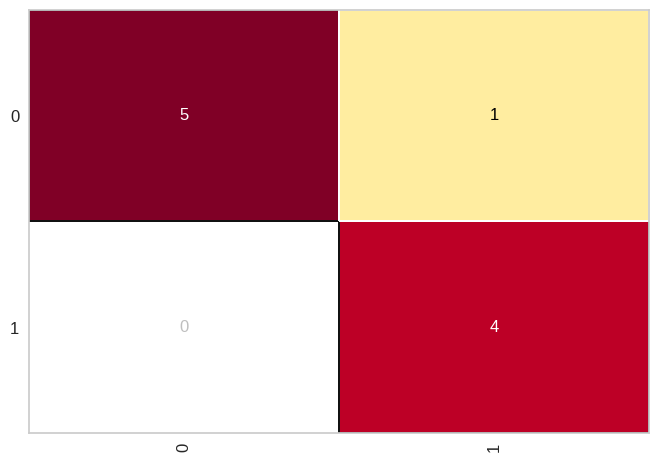

In [133]:
from yellowbrick.classifier import ConfusionMatrix

cm = ConfusionMatrix(modelo)
cm.fit(X_train, y_train)
cm.score(X_test, y_test)

## Relatório de classificação (precision, recall, f1-score)

In [134]:
relatorio = classification_report(y_test, y_pred)
print("Relatótio de classificação:")
print(relatorio)

Relatótio de classificação:
              precision    recall  f1-score   support

           0       1.00      0.83      0.91         6
           1       0.80      1.00      0.89         4

    accuracy                           0.90        10
   macro avg       0.90      0.92      0.90        10
weighted avg       0.92      0.90      0.90        10



## Verificando proporção de acertos

In [135]:
print("Distribuição real:")
print(y_test.value_counts())



Distribuição real:
target
0    6
1    4
Name: count, dtype: int64


In [136]:
print("Distribuição prevista:")
print(pd.Series(y_pred).value_counts())

Distribuição prevista:
1    5
0    5
Name: count, dtype: int64
